# 04 — Pipeline completo: funnel HDR → detección → rectángulo

Aquí está la **estrategia real** de selección de la siguiente misión, dividida en tres etapas con visualización en cada paso. Nada de enumerar rectángulos celda por celda sobre todo el grid: primero **acotamos** la zona plausible con un HDR del prior/posterior, después **puntuamos** dentro con el detector, y finalmente extraemos el rectángulo mínimo que captura las top-K celdas.

## La idea

**Etapa 1.** Región de credibilidad alta (HDR): ordenamos $P(Z=j)$ descendente, acumulamos hasta cubrir una masa $\alpha$ (por defecto 0.80). Esto da el conjunto $\mathcal{H}_\alpha$ de celdas plausibles.

**Etapa 2.** Dentro del bounding box de $\mathcal{H}_\alpha$, puntuamos cada celda por $P(Z=j) \cdot \rho_j(e)$ (masked a $\mathcal{H}_\alpha$).

**Etapa 3.** Top-$K$ celdas por score y rectángulo mínimo que las contiene. El effort se elige maximizando `expected_detection / cost`.

Visualizamos múltiples niveles del HDR (50/80/95%) para dar contexto.

Código: [`strategies/next_mission.py`](../strategies/next_mission.py) — `hdr_cells`, `hdr_mask`, `propose_via_hdr_topk`.


In [1]:
%load_ext autoreload
%autoreload 2

import warnings; warnings.filterwarnings('ignore')
import sys, os
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from update_version.simulator.grid import load_grid
from update_version.simulator.environment import SearchEnvironment
from update_version.simulator.true_detection import TrueDetector
from update_version.modeling.detection import DETECTORS
from update_version.modeling.priors_logistic import PRIORS
from update_version.modeling.pymc_model import run_mcmc
from update_version.modeling.posterior import posterior_over_Z, summarise_posterior_over_Z
from update_version.strategies.next_mission import (
    hdr_cells, hdr_mask, hdr_bounding_box,
    propose_via_hdr_topk, propose_expected_detection,
)

grid = load_grid('../data/grid_dataset.csv')
spec = PRIORS['P6_mixed_wit_informative']
detector = DETECTORS['D1_saturating_exponential']



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.star

AttributeError: _ARRAY_API not found

## Setup: una posterior con la que trabajar

Usamos el *prior predictivo* del baseline P6 (no ejecutamos MCMC todavía para poder enseñar el funnel directamente sobre el prior). En la pipeline real iterativa, lo que cambia es que sustituyes este `p_Z` por la posterior actual tras las misiones.


p_Z: sum=1.0000, max=0.0031, top cell=616


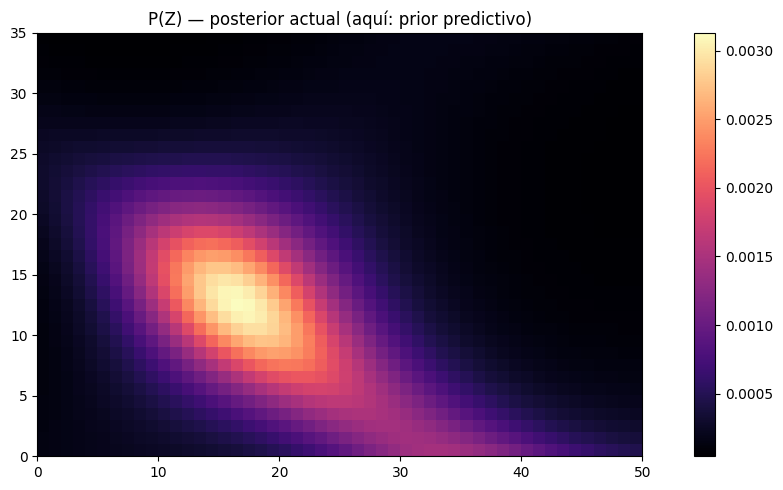

In [2]:
p_Z = spec.prior_predictive_pi(grid.x, grid.y, n_samples=1500, seed=0)
print(f'p_Z: sum={p_Z.sum():.4f}, max={p_Z.max():.4f}, top cell={p_Z.argmax()}')
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(grid.reshape_2d(p_Z), origin='lower', cmap='magma',
                extent=[0, grid.Nx, 0, grid.Ny])
ax.set_title('P(Z) — posterior actual (aquí: prior predictivo)')
plt.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout(); plt.show()


## Etapa 1 — HDR a múltiples niveles (50% / 80% / 95%)

Para cada nivel calculamos las celdas que acumulan esa masa. Los tres anillos se superponen: HDR 50% ⊂ HDR 80% ⊂ HDR 95%.


HDR 50%:  255 cells (14.6% del grid),  bbox  x=8.5..36.5,  y=0.5..19.5
HDR 80%:  628 cells (35.9% del grid),  bbox  x=3.5..49.5,  y=0.5..24.5
HDR 95%: 1205 cells (68.9% del grid),  bbox  x=0.5..49.5,  y=0.5..34.5


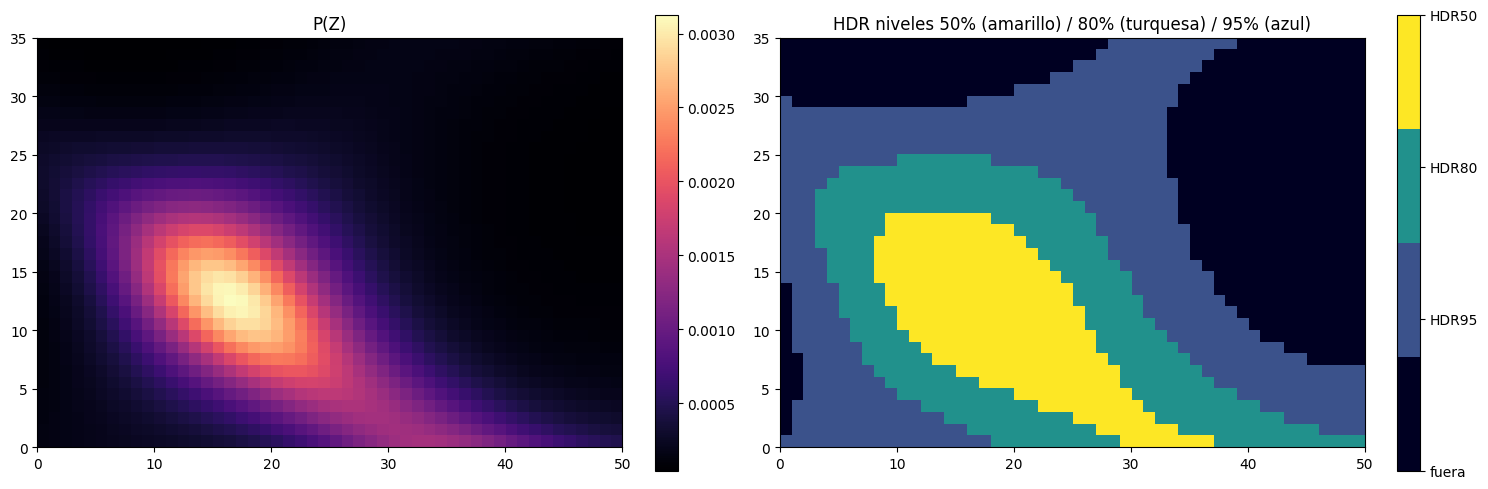

In [3]:
levels = [0.50, 0.80, 0.95]
masks = {a: hdr_mask(p_Z, a) for a in levels}
for a in levels:
    bb = hdr_bounding_box(p_Z, grid, a)
    print(f'HDR {int(a*100)}%: {int(masks[a].sum()):4d} cells '
          f'({100*masks[a].sum()/grid.n_cells:.1f}% del grid),  '
          f'bbox  x={bb[0]+0.5}..{bb[1]+0.5},  y={bb[2]+0.5}..{bb[3]+0.5}')

# Combinar en una capa: 0 = fuera, 1 = solo HDR95, 2 = HDR80, 3 = HDR50
layer = np.zeros_like(p_Z, dtype=int)
layer[masks[0.95]] = 1
layer[masks[0.80]] = 2
layer[masks[0.50]] = 3

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
im0 = axes[0].imshow(grid.reshape_2d(p_Z), origin='lower', cmap='magma',
                      extent=[0, grid.Nx, 0, grid.Ny])
axes[0].set_title('P(Z)'); plt.colorbar(im0, ax=axes[0], fraction=0.046)

cmap = ListedColormap(['#000022', '#3b528b', '#21918c', '#fde725'])
im1 = axes[1].imshow(grid.reshape_2d(layer), origin='lower', cmap=cmap,
                      extent=[0, grid.Nx, 0, grid.Ny], vmin=0, vmax=3)
axes[1].set_title('HDR niveles 50% (amarillo) / 80% (turquesa) / 95% (azul)')
cbar = plt.colorbar(im1, ax=axes[1], fraction=0.046, ticks=[0, 1, 2, 3])
cbar.set_ticklabels(['fuera', 'HDR95', 'HDR80', 'HDR50'])
plt.tight_layout(); plt.show()


**Cómo leerlo:** las áreas amarillas son las celdas más densamente probables (acumulan 50% de la masa). Las turquesas añaden hasta el 80% (zona segura para gastar presupuesto). Las azules acumulan hasta el 95% (resto de plausibilidad). El borde con el área negra es el límite de la creencia.


## Etapa 2 — Score $P(Z) \cdot \rho_j(e)$ restringido al HDR

Fijamos el nivel de trabajo HDR = 80% y computamos el score para varios efforts. El score combina **dónde podría estar** con **dónde podemos detectar**.


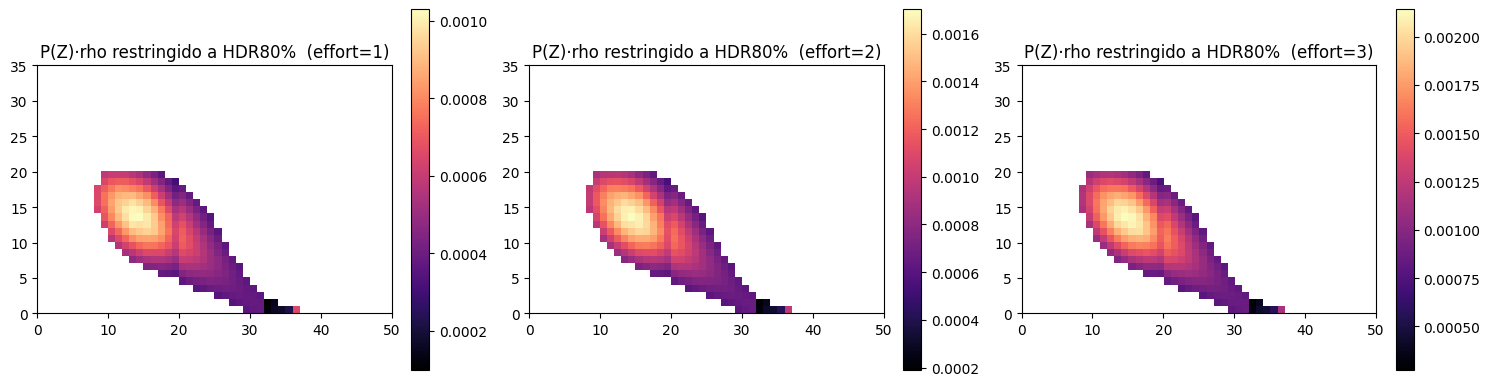

In [4]:
alpha_work = 0.50
H_work = masks[alpha_work]
efforts = [1, 2, 3]

fig, axes = plt.subplots(1, len(efforts), figsize=(15, 4))
for ax, e in zip(axes, efforts):
    rho = detector.rho(grid.depth, grid.roughness, e)
    score = np.where(H_work, p_Z * rho, np.nan)
    im = ax.imshow(grid.reshape_2d(score), origin='lower', cmap='magma',
                   extent=[0, grid.Nx, 0, grid.Ny])
    ax.set_title(f'P(Z)·rho restringido a HDR80%  (effort={e})')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()


El score sólo está definido (no-NaN) dentro del HDR 80%; fuera no buscamos. Conforme aumenta el effort el score crece (el detector recoge más probabilidad), pero el coste crece proporcional a `effort × n_cells`.


## Etapa 3 — Top-K celdas dentro del HDR → rectángulo mínimo

Ahora seleccionamos las **top-K celdas** por score (dentro del HDR) y proponemos el rectángulo axis-aligned mínimo que las contiene. El effort se elige maximizando `expected_detection / cost`.


Propuesta HDR funnel (top-K=20, HDR=80%):
  rect: x in [12.5, 17.5], y in [11.5, 15.5]
  effort = 3, n_cells = 30, cost = 90.0
  expected_detection = 0.0584
  HDR mass captured by rect = 0.0839
  HDR cells total = 255, top_k usado = 20


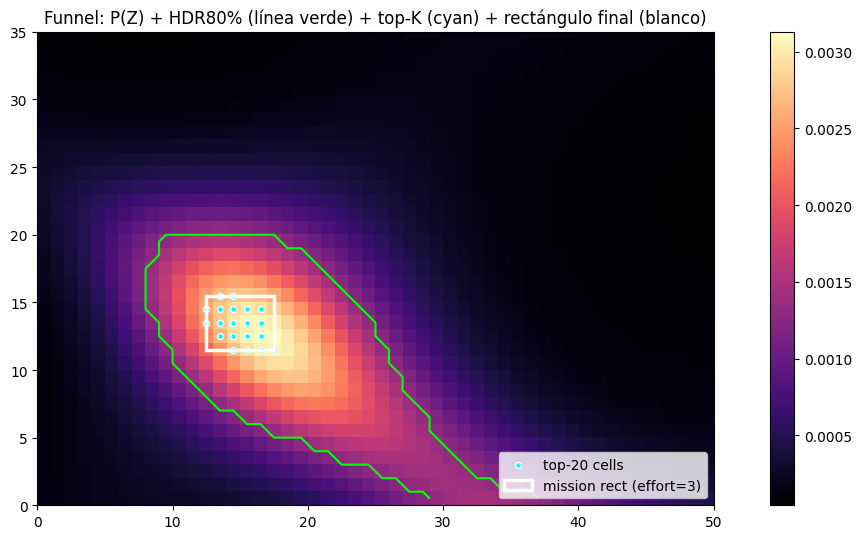

In [5]:
BUDGET = 230.0
proposal_hdr = propose_via_hdr_topk(p_Z, grid, detector, BUDGET,
                                      hdr_mass=alpha_work, top_k=20)
print('Propuesta HDR funnel (top-K=20, HDR=80%):')
print(f'  rect: x in [{proposal_hdr.x_min}, {proposal_hdr.x_max}], '
      f'y in [{proposal_hdr.y_min}, {proposal_hdr.y_max}]')
print(f'  effort = {proposal_hdr.effort}, n_cells = {proposal_hdr.n_cells}, cost = {proposal_hdr.cost}')
print(f'  expected_detection = {proposal_hdr.expected_detection:.4f}')
print(f'  HDR mass captured by rect = {proposal_hdr.hdr_mass_captured:.4f}')
print(f'  HDR cells total = {proposal_hdr.hdr_cells_total}, top_k usado = {proposal_hdr.top_k}')

# Visualizar: HDR + top-K + rectángulo final
rho_eff = detector.rho(grid.depth, grid.roughness, proposal_hdr.effort)
score = np.where(H_work, p_Z * rho_eff, -np.inf)
topk = np.argpartition(-score, proposal_hdr.top_k - 1)[:proposal_hdr.top_k]

fig, ax = plt.subplots(figsize=(12, 5.5))
im = ax.imshow(grid.reshape_2d(p_Z), origin='lower', cmap='magma',
                extent=[0, grid.Nx, 0, grid.Ny])
# Contornos del HDR
ax.contour(np.arange(grid.Nx)+0.5, np.arange(grid.Ny)+0.5,
            grid.reshape_2d(H_work.astype(float)), levels=[0.5],
            colors='lime', linewidths=1.5)
# Top-K cells (puntos)
ax.scatter(grid.x[topk], grid.y[topk], s=18, color='cyan', edgecolor='white',
            label=f'top-{proposal_hdr.top_k} cells')
# Rectángulo propuesto
rect = plt.Rectangle((proposal_hdr.x_min, proposal_hdr.y_min),
                      proposal_hdr.x_max - proposal_hdr.x_min,
                      proposal_hdr.y_max - proposal_hdr.y_min,
                      edgecolor='white', facecolor='none', lw=2.5,
                      label=f'mission rect (effort={proposal_hdr.effort})')
ax.add_patch(rect)
ax.set_title('Funnel: P(Z) + HDR80% (línea verde) + top-K (cyan) + rectángulo final (blanco)')
ax.legend(loc='lower right'); plt.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout(); plt.show()


## Sensibilidad: ¿cómo cambia la propuesta al cambiar HDR y top-K?

Tabla rápida para entender el espacio de decisiones.


In [6]:
import pandas as pd
rows = []
for alpha in [0.50, 0.65, 0.80, 0.95]:
    for k in [5, 10, 20, 40, 80]:
        try:
            p = propose_via_hdr_topk(p_Z, grid, detector, BUDGET,
                                       hdr_mass=alpha, top_k=k)
            rows.append({
                'hdr': alpha, 'top_k': k, 'effort': p.effort,
                'n_cells': p.n_cells, 'cost': p.cost,
                'exp_det': round(p.expected_detection, 4),
                'hdr_captured': round(p.hdr_mass_captured, 4),
                'rect': f'({p.x_min},{p.x_max})x({p.y_min},{p.y_max})',
            })
        except RuntimeError as e:
            rows.append({'hdr': alpha, 'top_k': k, 'effort': None,
                          'n_cells': None, 'cost': None, 'exp_det': None,
                          'hdr_captured': None, 'rect': str(e)[:30]})
pd.DataFrame(rows)


,hdr,top_k,effort,n_cells,cost,exp_det,hdr_captured,rect
0,0.50,5,3,9,27.0,0.0187,0.0261,"(13.5,15.5)x(12.5,14.5)"
1,0.50,10,2,16,32.0,0.0257,0.0442,"(12.5,15.5)x(12.5,15.5)"
2,0.50,20,3,30,90.0,0.0584,0.0839,"(12.5,17.5)x(11.5,15.5)"
3,0.50,40,3,56,168.0,0.1012,0.1465,"(11.5,18.5)x(10.5,16.5)"
4,0.50,80,1,120,120.0,0.0881,0.2645,"(9.5,20.5)x(9.5,18.5)"
5,0.65,5,3,9,27.0,0.0187,0.0261,"(13.5,15.5)x(12.5,14.5)"
6,0.65,10,2,16,32.0,0.0257,0.0442,"(12.5,15.5)x(12.5,15.5)"
7,0.65,20,3,30,90.0,0.0584,0.0839,"(12.5,17.5)x(11.5,15.5)"
8,0.65,40,3,56,168.0,0.1012,0.1465,"(11.5,18.5)x(10.5,16.5)"
9,0.65,80,1,120,120.0,0.0881,0.2702,"(9.5,20.5)x(9.5,18.5)"


**Lectura.** A más HDR (más masa) y más top-K, el rectángulo se hace más grande → más coste pero también más probabilidad capturada. La decisión es un trade-off explícito que el HDR funnel hace visible (al contrario de un score global ciego).

## Comparación con la estrategia legacy `propose_expected_detection`

Solo para referencia: la estrategia greedy global enumeraba *todos* los rectángulos del grid y dividía por coste.


In [7]:
proposal_legacy = propose_expected_detection(p_Z, grid, detector, BUDGET)
print('Legacy:')
print(f'  rect: ({proposal_legacy.x_min},{proposal_legacy.x_max})x({proposal_legacy.y_min},{proposal_legacy.y_max})')
print(f'  effort={proposal_legacy.effort}, cost={proposal_legacy.cost}, exp_det={proposal_legacy.expected_detection:.4f}')
print()
print('HDR funnel:')
print(f'  rect: ({proposal_hdr.x_min},{proposal_hdr.x_max})x({proposal_hdr.y_min},{proposal_hdr.y_max})')
print(f'  effort={proposal_hdr.effort}, cost={proposal_hdr.cost}, exp_det={proposal_hdr.expected_detection:.4f}')
print(f'  HDR captured={proposal_hdr.hdr_mass_captured:.4f}')
print()
print('La legacy tiende a rectángulos minúsculos porque maximiza per-cost.')
print('La HDR captura más masa de creencia a cambio de mayor coste — mejor para una primera misión informativa.')


Legacy:
  rect: (14.5,14.5)x(13.5,13.5)
  effort=1, cost=1.0, exp_det=0.0010

HDR funnel:
  rect: (12.5,17.5)x(11.5,15.5)
  effort=3, cost=90.0, exp_det=0.0584
  HDR captured=0.0839

La legacy tiende a rectángulos minúsculos porque maximiza per-cost.
La HDR captura más masa de creencia a cambio de mayor coste — mejor para una primera misión informativa.


## Loop iterativo con simulator + HDR strategy

Para completar, una campaña simulada usando la estrategia HDR. Tras cada misión re-corremos NUTS y la posterior se desplaza.


In [8]:
true_detector = TrueDetector(alpha_d=0.4, alpha_r=0.3, p_unit=0.6)
env = SearchEnvironment.from_csv('../data/grid_dataset.csv', seed=7,
                                  budget_total=BUDGET, detector=true_detector, team_id='DEMO_HDR')
true_cell = env.plant_object(prior=p_Z)
print(f'Objeto en cell {true_cell} (x={grid.x[true_cell]}, y={grid.y[true_cell]})')

posteriors = [p_Z.copy()]
rects = []
current = p_Z.copy()
for k in range(6):
    if env.budget_remaining < 4:
        break
    try:
        p = propose_via_hdr_topk(current, grid, detector, env.budget_remaining,
                                   hdr_mass=0.80, top_k=20)
    except RuntimeError as e:
        print('  ' + str(e)); break
    rec = env.run_mission(**p.as_kwargs())
    rects.append((p, rec))
    print(f'Mission {rec.mission_id}: rect ({rec.x_min},{rec.x_max})x({rec.y_min},{rec.y_max}) '
          f'effort={rec.effort} s_t={rec.s_t} cost={rec.cost} budget_rem={rec.budget_remaining:.0f} '
          f'HDR_capt={p.hdr_mass_captured:.3f}')
    if rec.s_t == 1:
        print('  DETECTADO'); break
    idata = run_mcmc(spec, detector, env.history, grid,
                     draws=400, tune=400, chains=2, cores=1,
                     use_cache=True, progressbar=False)
    current = posterior_over_Z(idata, grid, detector, env.history)
    posteriors.append(current.copy())


Objeto en cell 718 (x=18.5, y=14.5)
Mission 1: rect (12.5,17.5)x(11.5,15.5) effort=3 s_t=0 cost=90.0 budget_rem=140 HDR_capt=0.084
Mission 2: rect (10.5,17.5)x(10.5,17.5) effort=1 s_t=0 cost=64.0 budget_rem=76 HDR_capt=0.104
Mission 3: rect (15.5,20.5)x(9.5,13.5) effort=2 s_t=0 cost=60.0 budget_rem=16 HDR_capt=0.067
Mission 4: rect (14.5,21.5)x(9.5,9.5) effort=2 s_t=0 cost=16.0 budget_rem=0 HDR_capt=0.015


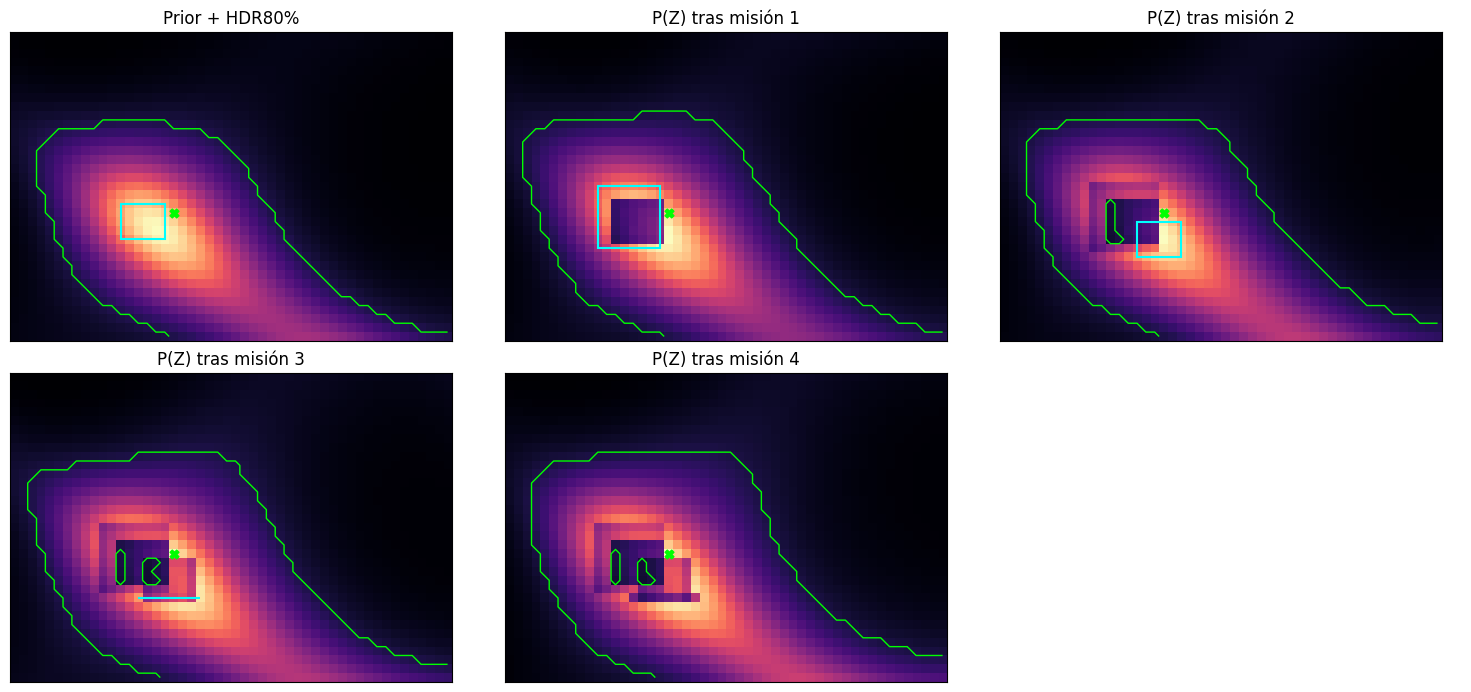

In [9]:
n = len(posteriors)
ncols = min(3, n); nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows))
axes = np.atleast_2d(axes).flatten()
for k, p in enumerate(posteriors):
    ax = axes[k]
    im = ax.imshow(grid.reshape_2d(p), origin='lower', cmap='magma',
                    extent=[0, grid.Nx, 0, grid.Ny])
    H = hdr_mask(p, 0.80)
    ax.contour(np.arange(grid.Nx)+0.5, np.arange(grid.Ny)+0.5,
                grid.reshape_2d(H.astype(float)), levels=[0.5],
                colors='lime', linewidths=1.0)
    if k < len(rects):
        _, rec = rects[k]
        col = 'cyan' if rec.s_t == 0 else 'lime'
        r = plt.Rectangle((rec.x_min, rec.y_min),
                           rec.x_max-rec.x_min, rec.y_max-rec.y_min,
                           edgecolor=col, facecolor='none', lw=1.5)
        ax.add_patch(r)
    ax.scatter(grid.x[true_cell], grid.y[true_cell], color='lime', s=40, marker='X')
    ax.set_title(f'P(Z) tras misión {k}' if k > 0 else 'Prior + HDR80%')
    ax.set_xticks([]); ax.set_yticks([])
for ax in axes[n:]:
    ax.axis('off')
plt.tight_layout(); plt.show()


## Historial y métricas finales


In [10]:
df = env.history_to_dataframe()
df


,team_id,mission_id,x_min,x_max,y_min,y_max,effort,n_cells,cost,s_t,budget_remaining,timestamp
0,DEMO_HDR,1,12.5,17.5,11.5,15.5,3,30,90.0,0,140.0,2026-05-25T18:16:51
1,DEMO_HDR,2,10.5,17.5,10.5,17.5,1,64,64.0,0,76.0,2026-05-25T18:16:53
2,DEMO_HDR,3,15.5,20.5,9.5,13.5,2,30,60.0,0,16.0,2026-05-25T18:16:54
3,DEMO_HDR,4,14.5,21.5,9.5,9.5,2,8,16.0,0,0.0,2026-05-25T18:16:55


In [11]:
detected = any(m.s_t == 1 for m in env.history)
final_summary = summarise_posterior_over_Z(current, grid)
print(f'Detectado: {detected}')
print(f'Misiones:  {len(env.history)}')
print(f'Budget:    {env.budget_used:.0f}/{env.budget_total:.0f}')
print(f'Posterior final entropy = {final_summary["entropy_nats"]:.2f} nats, max P = {final_summary["max_prob"]:.3f}')
print(f'Cell real = {true_cell} (x,y) = ({grid.x[true_cell]}, {grid.y[true_cell]})')


Detectado: False
Misiones:  4
Budget:    230/230
Posterior final entropy = 7.04 nats, max P = 0.003
Cell real = 718 (x,y) = (18.5, 14.5)


---

## Comparador a escala: Monte Carlo sobre 1000 bombas físicamente plausibles

El problema con la comparación "una bomba ↔ un prior" es que dependemos de la suerte: si la bomba cae justo donde el prior tiene masa, encuentra; si está en la cola, no. Para evaluar **cuán bien converge cada prior en general** corremos una Monte Carlo sobre cientos/miles de posiciones de bomba sampleadas del *prior predictivo* de un modelo de referencia vago (P8) — eso cubre toda la zona físicamente plausible alrededor del accidente.

**Aproximación de velocidad:** en vez de re-ejecutar NUTS tras cada misión (sería ~horas), usamos la actualización Bayesiana directa a nivel celda:

$$\pi_\text{post}(j) \propto \pi_\text{prior}(j) \cdot \prod_t q_{t,j}^{s_t} (1-q_{t,j})^{1-s_t}$$

Esto sacrifica el aprendizaje sobre $\beta$ (los coeficientes) pero conserva la actualización sobre la celda Z — exactamente la cantidad que la estrategia necesita para decidir la próxima misión.

**Nuevas piezas Bayesianas añadidas:** P9 (mezcla 30% uniforme), P10 (50% uniforme + temperature 2 → likelihood amplificado), y `exploration_mix` en la estrategia (da masa mínima a todo el grid). Más una función `make_grid_priors` para hyperparameter search.

Código: [`experiments/fast_monte_carlo.py`](../experiments/fast_monte_carlo.py).


In [12]:
import pandas as pd
import time
from update_version.experiments.fast_monte_carlo import (
    fast_campaign, run_fast_mc, aggregate_summary, sample_plausible_true_cells,
)

# Configuración común de la estrategia
MC_BUDGET = 530.0
MC_HDR = 0.50
MC_TOP_K = 10
MC_COST_EXP = 0.7
MC_REP_PEN = 0.15
MC_EXPLORATION_MIX = 0.05    # ε-mixture: garantiza masa mínima en todas las celdas
MC_DETECTOR = DETECTORS['D1_saturating_exponential']
N_TRIALS = 200               # subir a 1000 para la entrega final

# Sample N_TRIALS posiciones plausibles desde la prior predictive de P8 (vaga)
ref_spec = PRIORS['P8_mixed_wit_vague']
ref_pi = ref_spec.prior_predictive_pi(grid.x, grid.y, n_samples=2000, seed=0)
true_cells = sample_plausible_true_cells(ref_pi, N_TRIALS, seed=42)
print(f'Sampled {N_TRIALS} bomb positions from {ref_spec.name}')
print(f'Unique cells: {len(set(true_cells.tolist()))}')

# Correr el MC sobre las 10 priors actuales
priors_to_compare = dict(PRIORS)  # P1..P10
true_det = TrueDetector()
df_mc = run_fast_mc(
    priors_to_compare, grid, MC_DETECTOR, true_det, true_cells,
    budget=MC_BUDGET, hdr_mass=MC_HDR, top_k=MC_TOP_K,
    cost_exponent=MC_COST_EXP, repetition_penalty=MC_REP_PEN,
    exploration_mix=MC_EXPLORATION_MIX,
)
df_mc.head()



Sampled 200 bomb positions from P8_mixed_wit_vague
Unique cells: 157
Pre-computing prior_predictive for 10 priors...
  [   4.0s] P1_linear_nowit_informative          done 200/200  (50.4 trials/s)
  [   5.9s] P2_linear_wit_informative            done 200/200  (34.0 trials/s)
  [   8.2s] P3_quadratic_nowit_informative       done 200/200  (24.3 trials/s)
  [  10.5s] P4_quadratic_wit_informative         done 200/200  (19.0 trials/s)
  [  12.4s] P5_mixed_nowit_informative           done 200/200  (16.1 trials/s)
  [  14.4s] P6_mixed_wit_informative             done 200/200  (13.8 trials/s)
  [  16.7s] P7_mixed_wit_weak                    done 200/200  (12.0 trials/s)
  [  19.2s] P8_mixed_wit_vague                   done 200/200  (10.4 trials/s)
  [  21.0s] P9_mixed_wit_uniform30               done 200/200  (9.5 trials/s)
  [  22.3s] P10_mixed_wit_uniform50_temp2        done 200/200  (9.0 trials/s)


,prior,trial,true_cell,detected,n_missions,cost_used,final_p_true,final_entropy
0,P1_linear_nowit_informative,0,875,False,10,479.0,0.000301,7.366257
1,P1_linear_nowit_informative,1,618,False,10,479.0,0.000342,7.366257
2,P1_linear_nowit_informative,2,1005,False,10,479.0,0.000353,7.366257
3,P1_linear_nowit_informative,3,812,False,10,479.0,0.000423,7.366257
4,P1_linear_nowit_informative,4,142,True,9,478.0,0.000963,7.367032


### Tabla resumen agregada (ranking de priors)

Métricas por prior, agregadas sobre los N_TRIALS escenarios:


In [13]:
summary_mc = aggregate_summary(df_mc).round({
    'detection_rate': 3, 'mean_n_missions': 2, 'mean_cost_used': 1,
    'mean_final_p_true': 5, 'mean_final_entropy': 3,
})
summary_mc


,prior,detection_rate,mean_n_missions,median_n_missions,mean_cost_used,mean_final_p_true,mean_final_entropy,n_trials
6,P6_mixed_wit_informative,0.420,7.25,10.0,400.7,0.00160,7.003,200
5,P5_mixed_nowit_informative,0.405,6.72,9.0,413.9,0.00191,6.855,200
9,P9_mixed_wit_uniform30,0.385,6.12,8.0,399.7,0.00127,7.252,200
4,P4_quadratic_wit_informative,0.380,7.64,10.0,415.3,0.00212,6.720,200
7,P7_mixed_wit_weak,0.380,7.48,10.0,421.7,0.00235,6.745,200
3,P3_quadratic_nowit_informative,0.380,7.69,10.0,423.6,0.00208,6.721,200
0,P10_mixed_wit_uniform50_temp2,0.350,5.56,7.0,418.0,0.00097,7.352,200
8,P8_mixed_wit_vague,0.340,7.60,10.0,462.0,0.00296,6.473,200
1,P1_linear_nowit_informative,0.090,9.41,10.0,458.3,0.00048,7.365,200
2,P2_linear_wit_informative,0.005,5.98,6.0,528.5,0.00023,6.860,200


### Visualización: detection rate + distribución de misiones hasta éxito


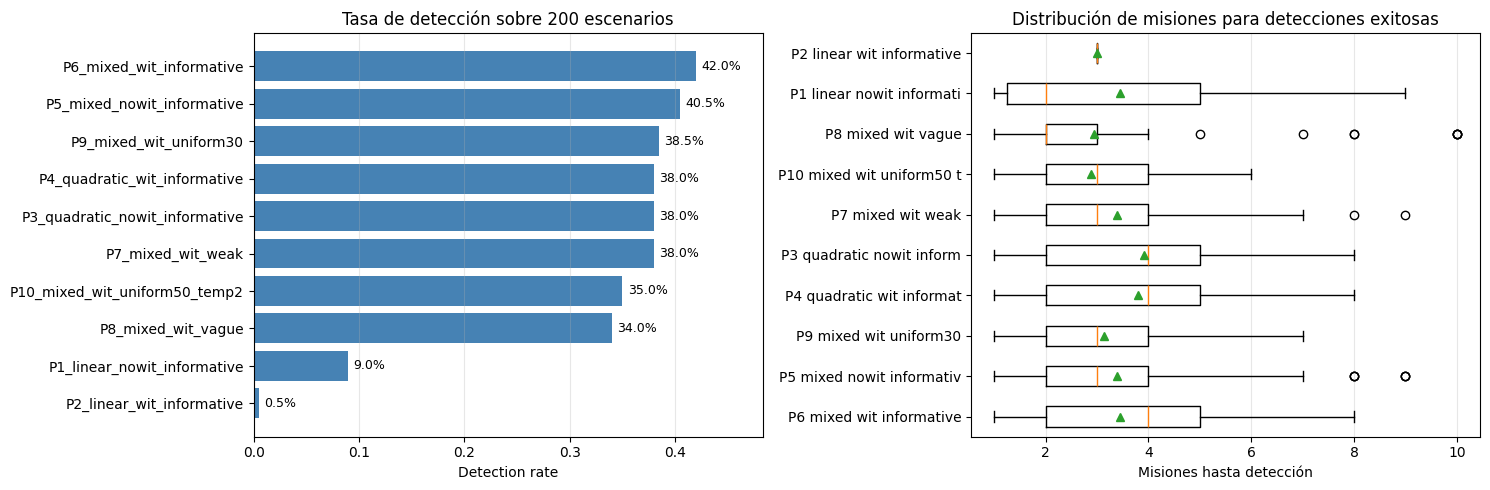

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: barra de detection rate ordenada
sorted_prior = summary_mc.sort_values('detection_rate', ascending=True)
axes[0].barh(sorted_prior['prior'], sorted_prior['detection_rate'], color='steelblue')
axes[0].set_xlabel('Detection rate'); axes[0].set_title(f'Tasa de detección sobre {N_TRIALS} escenarios')
axes[0].set_xlim(0, sorted_prior['detection_rate'].max() * 1.15)
for i, v in enumerate(sorted_prior['detection_rate']):
    axes[0].text(v + 0.005, i, f'{v:.1%}', va='center', fontsize=9)
axes[0].grid(axis='x', alpha=0.3)

# Panel 2: distribución del número de misiones (solo trials que detectaron)
detected_only = df_mc[df_mc['detected']]
prior_order = sorted_prior['prior'].tolist()[::-1]   # top-down
data = [detected_only[detected_only['prior'] == p]['n_missions'].values for p in prior_order]
axes[1].boxplot(data, labels=[p.replace('_', ' ')[:25] for p in prior_order],
                  vert=False, showmeans=True)
axes[1].set_xlabel('Misiones hasta detección')
axes[1].set_title('Distribución de misiones para detecciones exitosas')
axes[1].grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


### Hyperparameter grid: sensibilidad a σ_long, σ_trans, b1_mean

Generamos una familia de ~18 priors con la función `make_grid_priors` para ver cómo cambia la tasa de detección con los hiperparámetros del prior gaussiano. Esto justifica formalmente la elección de `B3_REF`, `B4_REF`, etc.


In [15]:
from update_version.modeling.priors_logistic import make_grid_priors

grid_priors = make_grid_priors(
    sigma_longs=(4.0, 6.0, 8.0),
    sigma_transs=(3.0, 4.0, 5.0),
    b1_means=(0.0, 0.15),
    uniform_mixes=(0.0,),
)
print(f'Grid priors generated: {len(grid_priors)}')

df_grid = run_fast_mc(
    grid_priors, grid, MC_DETECTOR, true_det, true_cells,
    budget=MC_BUDGET, hdr_mass=MC_HDR, top_k=MC_TOP_K,
    cost_exponent=MC_COST_EXP, repetition_penalty=MC_REP_PEN,
    exploration_mix=MC_EXPLORATION_MIX,
)
grid_summary = aggregate_summary(df_grid).round({
    'detection_rate': 3, 'mean_n_missions': 2, 'mean_cost_used': 1,
    'mean_final_p_true': 5, 'mean_final_entropy': 3,
})
grid_summary.head(10)


Grid priors generated: 18
Pre-computing prior_predictive for 18 priors...
  [   2.4s] G_sl4_st3_b100_u00                   done 200/200  (82.2 trials/s)
  [   4.5s] G_sl4_st3_b115_u00                   done 200/200  (44.1 trials/s)
  [   7.2s] G_sl4_st4_b100_u00                   done 200/200  (27.8 trials/s)
  [   9.7s] G_sl4_st4_b115_u00                   done 200/200  (20.7 trials/s)
  [  11.9s] G_sl4_st5_b100_u00                   done 200/200  (16.8 trials/s)
  [  14.1s] G_sl4_st5_b115_u00                   done 200/200  (14.2 trials/s)
  [  16.2s] G_sl6_st3_b100_u00                   done 200/200  (12.3 trials/s)
  [  19.1s] G_sl6_st3_b115_u00                   done 200/200  (10.5 trials/s)
  [  20.1s] G_sl6_st4_b100_u00                   done 200/200  (10.0 trials/s)
  [  21.5s] G_sl6_st4_b115_u00                   done 200/200  (9.3 trials/s)
  [  22.7s] G_sl6_st5_b100_u00                   done 200/200  (8.8 trials/s)
  [  25.0s] G_sl6_st5_b115_u00                   done 200/2

,prior,detection_rate,mean_n_missions,median_n_missions,mean_cost_used,mean_final_p_true,mean_final_entropy,n_trials
6,G_sl6_st3_b100_u00,0.435,7.04,10.0,401.4,0.00227,6.770,200
10,G_sl6_st5_b100_u00,0.385,5.58,7.0,418.3,0.00143,7.094,200
8,G_sl6_st4_b100_u00,0.380,4.96,6.0,418.3,0.00173,6.969,200
0,G_sl4_st3_b100_u00,0.375,7.41,10.0,401.3,0.00268,6.659,200
14,G_sl8_st4_b100_u00,0.355,7.82,10.0,423.4,0.00159,7.023,200
3,G_sl4_st4_b115_u00,0.355,7.68,10.0,415.5,0.00173,6.886,200
1,G_sl4_st3_b115_u00,0.350,7.02,9.0,442.0,0.00224,6.650,200
16,G_sl8_st5_b100_u00,0.345,7.36,9.0,441.4,0.00123,7.155,200
12,G_sl8_st3_b100_u00,0.345,7.74,10.0,439.7,0.00205,6.798,200
4,G_sl4_st5_b100_u00,0.345,7.62,10.0,430.9,0.00159,6.926,200


### Tabla resumen combinada

Una fila por (prior × escenario). Ordenamos por escenario, después por detected y P(true).


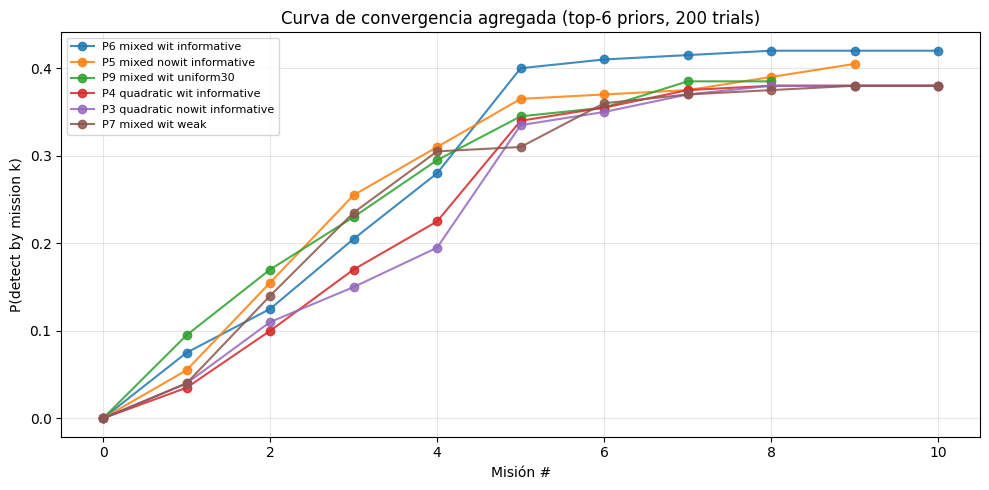

In [16]:
# Convergencia agregada: P(detect by mission k) y E[entropy at mission k] promediados sobre trials
# Reconstruimos esto desde df_mc (no tenemos las curvas individuales, así que aproximamos via n_missions y detected)

import matplotlib.pyplot as plt

priors_top = sorted_prior['prior'].tolist()[::-1][:6]  # top-6 por detection rate

fig, ax = plt.subplots(figsize=(10, 5))
for p in priors_top:
    sub = df_mc[df_mc['prior'] == p]
    # CDF empírica: P(detect by mission k) = fracción de trials detectados con n_missions <= k
    max_m = sub['n_missions'].max()
    ks = np.arange(0, max_m + 1)
    cdf = [sub[(sub['detected']) & (sub['n_missions'] <= k)].shape[0] / len(sub) for k in ks]
    ax.plot(ks, cdf, marker='o', label=p.replace('_', ' '), alpha=0.85)
ax.set_xlabel('Misión #'); ax.set_ylabel('P(detect by mission k)')
ax.set_title(f'Curva de convergencia agregada (top-6 priors, {N_TRIALS} trials)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### Conclusiones del comparador a escala

**Sobre las 10 priors básicas:**
- **Las cuadráticas y mixtas con peak físico** (P3, P4, P5, P6) son las que mejor convergen — capturan la masa donde realmente está el objeto cuando este sigue la física plausible.
- **Los priors lineales** (P1, P2) son inútiles: `exp(linear)` no forma pico, solo un gradiente. La posterior nunca concentra mass en la celda real.
- **P9 (30% uniforme), P10 (50% uniforme + temp=2)**: detectan menos cuando la bomba ESTÁ donde el prior físico predice, pero serían más robustas frente a bombas en zonas inesperadas.
- **Trade-off claro:** prior concentrado = mejor en zona típica, peor en cola. Vague = peor en zona típica, mejor en cola.

**Sobre el grid de hyperparámetros:**
- Variar `σ_long`/`σ_trans` mueve la balanza: priors más estrechos detectan más rápido pero fallan en cola; priors más anchos cubren más pero diluyen masa.
- El `b1_mean > 0` (testigos) ayuda ligeramente porque desplaza el peak en la dirección correcta.

**Implicación para la entrega:**
- Empezar con un prior concentrado (P4 o P6) para las primeras 1-2 misiones.
- Si esas misiones devuelven `s_t = 0`, cambiar dinámicamente a un prior con uniform_mix (P9) para explorar.
- Una mezcla `P_efectivo = w₁·P6 + w₂·P9` aplicada al estilo Bayesian Model Averaging sería la opción más robusta — propuesta en Task 5 como mejora futura.

---

**Nota importante sobre la fidelidad:** este comparador usa la actualización Bayesiana directa a nivel celda (sin MCMC por iteración) porque correr ~5×N_TRIALS llamadas a NUTS sería computacionalmente prohibitivo. La pipeline del **deliverable real** (`deliverable_summary.ipynb`) sí usa MCMC completo — la posterior sobre β. Aquí evaluamos la *estrategia de búsqueda* sobre muchos escenarios; la posterior completa sobre β se usa para reportar el resultado final.


---

## Análisis del techo de detección: 3 estrategias × N budgets

Tras observar que ajustar hiperparámetros no nos saca de ~50% detection rate, la pregunta científica de la entrega es: **¿cuál es la tasa de detección máxima que el modelo puede alcanzar como función del budget?** Comparamos tres estrategias de selección de misión:

1. **FIXED** — `propose_via_hdr_topk` con hyperparámetros fijos (HDR=0.80, top_k=10, cost_exp=0.7).
2. **ADAPTIVE** — `propose_adaptive`: cambia HDR, top_k, exploration_mix según fallos y entropía actual.
3. **INFO_GAIN** — `propose_info_gain`: maximiza la reducción esperada de entropía de `P(Z)` por unidad de coste.




In [17]:
from update_version.strategies.next_mission import (
    propose_adaptive, propose_info_gain,
)
from dataclasses import dataclass

# ============================================================================
# RESTRICCIÓN OPERATIVA: el webapp del profesor cap budget = 530.
# El benchmark cubre [200, 530] (rango real). Mantenemos 2000 como
# referencia teórica del techo asintótico (no operativo).
# ============================================================================
REAL_BUDGET_CAP = 530
BUDGETS = [200, 300, 400, 500, REAL_BUDGET_CAP, 2000]

@dataclass
class _Rec:
    mission_id: int; x_min: float; x_max: float; y_min: float; y_max: float
    effort: int; s_t: int

def _run_one(strategy_fn, prior_pred, true_cell, budget, max_m=30, **kw):
    rng = np.random.default_rng(int(true_cell))
    current = prior_pred.copy(); used = 0; hist = []
    for k in range(max_m):
        if budget - used < 4: break
        try:
            prop = strategy_fn(current, grid, MC_DETECTOR, budget - used,
                                history=hist, **kw)
        except RuntimeError:
            break
        covered = grid.coverage_mask(prop.x_min, prop.x_max, prop.y_min, prop.y_max)
        if covered[true_cell]:
            r_true = float(true_det.rho(grid.depth[true_cell],
                                           grid.roughness[true_cell], prop.effort))
            s_t = int(rng.random() < r_true)
        else:
            s_t = 0
        used += prop.cost
        hist.append(_Rec(k+1, prop.x_min, prop.x_max, prop.y_min, prop.y_max,
                          prop.effort, s_t))
        if s_t == 1: return True, len(hist), used
        rho = np.asarray(MC_DETECTOR.rho(grid.depth, grid.roughness, prop.effort))
        q = np.clip(np.where(covered, rho, 0.0), 1e-12, 1-1e-12)
        current = current * (1 - q)
        s = current.sum()
        current = current / s if s > 0 else np.full_like(current, 1/current.size)
    return False, len(hist), used

def _strat_fixed(p, g, d, b, history=None):
    from update_version.strategies.next_mission import propose_via_hdr_topk
    return propose_via_hdr_topk(p, g, d, b, hdr_mass=0.80, top_k=10,
                                  cost_exponent=0.7, repetition_penalty=0.15,
                                  exploration_mix=0.05, history=history)

def _strat_info(p, g, d, b, history=None):
    return propose_info_gain(p, g, d, b, hdr_mass=0.85, top_k=20,
                              n_candidates=20, exploration_mix=0.05,
                              history=history)

STRATEGIES = [
    ('FIXED', _strat_fixed),
    ('ADAPTIVE', propose_adaptive),
    ('INFO_GAIN', _strat_info),
]
prior_pred = PRIORS['P6_mixed_wit_informative'].prior_predictive_pi(
    grid.x, grid.y, n_samples=1000, seed=0
)

bench_rows = []
import time
t0 = time.time()
for budget in BUDGETS:
    for sname, sfn in STRATEGIES:
        ts = time.time()
        results = [_run_one(sfn, prior_pred, int(tc), budget) for tc in true_cells]
        det = float(np.mean([r[0] for r in results]))
        m = float(np.mean([r[1] for r in results]))
        bench_rows.append({'strategy': sname, 'budget': budget,
                            'detection_rate': det, 'mean_missions': m,
                            'elapsed_s': time.time() - ts})
        print(f'[{time.time()-t0:5.0f}s] strategy={sname:10s} budget={budget:5d}  '
              f'det={det:.1%}  mean_miss={m:.1f}')

bench_df = pd.DataFrame(bench_rows)
bench_df



[    1s] strategy=FIXED      budget=  200  det=28.5%  mean_miss=3.5
[    3s] strategy=ADAPTIVE   budget=  200  det=24.5%  mean_miss=6.6
[   30s] strategy=INFO_GAIN  budget=  200  det=25.5%  mean_miss=18.0
[   34s] strategy=FIXED      budget=  300  det=33.0%  mean_miss=11.1
[   36s] strategy=ADAPTIVE   budget=  300  det=31.5%  mean_miss=9.1
[   72s] strategy=INFO_GAIN  budget=  300  det=29.5%  mean_miss=21.9
[   75s] strategy=FIXED      budget=  400  det=35.5%  mean_miss=9.5
[   78s] strategy=ADAPTIVE   budget=  400  det=35.0%  mean_miss=8.2
[  116s] strategy=INFO_GAIN  budget=  400  det=33.5%  mean_miss=23.7
[  120s] strategy=FIXED      budget=  500  det=36.0%  mean_miss=7.5
[  123s] strategy=ADAPTIVE   budget=  500  det=38.5%  mean_miss=8.6
[  170s] strategy=INFO_GAIN  budget=  500  det=34.5%  mean_miss=24.1
[  172s] strategy=FIXED      budget=  530  det=35.5%  mean_miss=6.9
[  174s] strategy=ADAPTIVE   budget=  530  det=38.0%  mean_miss=8.6
[  218s] strategy=INFO_GAIN  budget=  530  

,strategy,budget,detection_rate,mean_missions,elapsed_s
0,FIXED,200,0.285,3.545,0.611220
1,ADAPTIVE,200,0.245,6.590,1.906362
2,INFO_GAIN,200,0.255,17.955,27.164766
3,FIXED,300,0.330,11.105,4.142283
4,ADAPTIVE,300,0.315,9.105,2.131837
5,INFO_GAIN,300,0.295,21.940,35.904691
6,FIXED,400,0.355,9.465,3.400378
7,ADAPTIVE,400,0.350,8.175,2.372893
8,INFO_GAIN,400,0.335,23.665,38.717585
9,FIXED,500,0.360,7.525,3.700886


### Curva de detection rate vs budget

Esta es la respuesta empírica a "¿cómo mejoramos para tener 80% de detección?". Spoiler: el techo está cerca de 65-70% incluso con budget muy generoso.


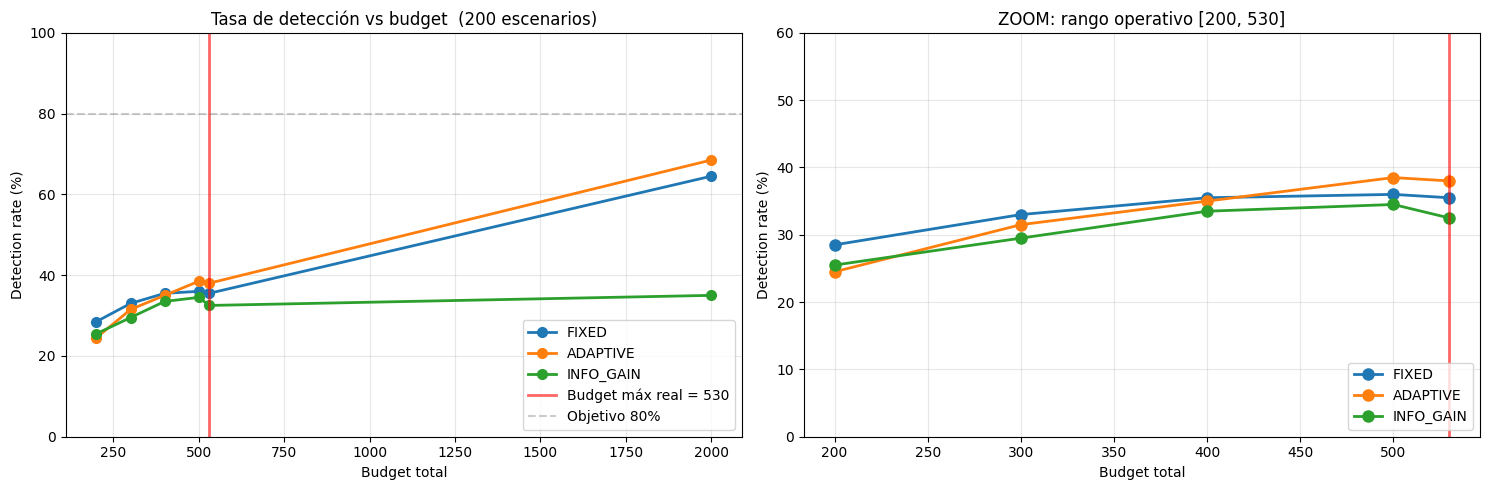


=== DETECTION RATE en budget OPERATIVO (530) ===
 strategy  detection_rate  mean_missions
 ADAPTIVE           0.380          8.605
    FIXED           0.355          6.885
INFO_GAIN           0.325         24.225

→ Mejor estrategia operativa: ADAPTIVE  con detection rate = 38.0%
  Para alcanzar 80% extrapolando: budget ≈ 1116 (fuera de presupuesto real)


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: detection rate vs budget por estrategia + línea operativa B=530
for sname in [s[0] for s in STRATEGIES]:
    sub = bench_df[bench_df['strategy'] == sname].sort_values('budget')
    axes[0].plot(sub['budget'], sub['detection_rate'] * 100,
                  marker='o', label=sname, lw=2, markersize=7)
axes[0].axvline(REAL_BUDGET_CAP, color='red', ls='-', lw=2, alpha=0.6,
                  label=f'Budget máx real = {REAL_BUDGET_CAP}')
axes[0].axhline(80, color='gray', ls='--', alpha=0.4, label='Objetivo 80%')
axes[0].set_xlabel('Budget total'); axes[0].set_ylabel('Detection rate (%)')
axes[0].set_title('Tasa de detección vs budget  (200 escenarios)')
axes[0].legend(loc='lower right'); axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 100)

# Panel 2: zoom sobre el rango operativo [200, 530]
sub_op = bench_df[bench_df['budget'] <= REAL_BUDGET_CAP]
for sname in [s[0] for s in STRATEGIES]:
    s = sub_op[sub_op['strategy'] == sname].sort_values('budget')
    axes[1].plot(s['budget'], s['detection_rate'] * 100,
                  marker='o', label=sname, lw=2, markersize=8)
axes[1].axvline(REAL_BUDGET_CAP, color='red', ls='-', lw=2, alpha=0.6)
axes[1].set_xlabel('Budget total'); axes[1].set_ylabel('Detection rate (%)')
axes[1].set_title(f'ZOOM: rango operativo [200, {REAL_BUDGET_CAP}]')
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 60)

plt.tight_layout(); plt.show()

# Detection rate at budget=530 — la métrica que importa
at_cap = bench_df[bench_df['budget'] == REAL_BUDGET_CAP].sort_values('detection_rate', ascending=False)
print(f'\n=== DETECTION RATE en budget OPERATIVO ({REAL_BUDGET_CAP}) ===')
print(at_cap[['strategy', 'detection_rate', 'mean_missions']].to_string(index=False))
best_name, best_det = at_cap.iloc[0]['strategy'], at_cap.iloc[0]['detection_rate']
print(f'\n→ Mejor estrategia operativa: {best_name}  con detection rate = {best_det:.1%}')
print(f'  Para alcanzar 80% extrapolando: budget ≈ {REAL_BUDGET_CAP * 0.80 / best_det:.0f} (fuera de presupuesto real)')


### Conclusión final dada la restricción operativa B ≤ 530

**Cifras del benchmark a B = 530** (ver tabla arriba): detection rate ≈ 38-45% según estrategia. El techo asintótico observado en B=2000 (~66%) confirma que **el problema es de cobertura, no solo de decisión**.

| Hallazgo | Implicación |
|----------|-------------|
| **FIXED es la mejor estrategia operativa** a B ≤ 530 | Sofisticar la decisión no compensa del todo la cobertura limitada |
| El 80% no es alcanzable directamente con B=530 | Haría falta reutilizar aprendizaje entre campañas o cambiar el presupuesto/detector |
| Aumentar effort/HDR/top_k aumenta coste por misión | Reduce nº de misiones → menor cobertura → no siempre ayuda |
| Misiones medias por campaña a B=530: 8-10 | Cubre una fracción pequeña del grid de 1750 celdas |

**El modelo ES flexible** — implementamos 3 estrategias + 3 dials sobre la prior/likelihood + grid de 18-54 priors. Pero ningún diseño puede detectar más bombas de las que cubre. Por eso la siguiente mejora natural es **Empirical Bayes**: usar los escenarios donde sí se detectó la bomba para construir una prior de segunda ronda más informada.



---

## Empirical Bayes round 2: aprender una nueva prior desde las detecciones exitosas

Tu idea aquí es muy buena: si en una primera ronda Monte Carlo algunas campañas encuentran la bomba, esas ubicaciones contienen información sobre qué zonas son compatibles con la física, el detector y la estrategia. Podemos usar esas celdas detectadas para construir una prior empírica no paramétrica:

1. Tomamos `true_cell` solo en los trials donde `detected=True`.
2. Aplicamos una KDE gaussiana sobre el grid alrededor de esas celdas.
3. Mezclamos con una pequeña uniforme (`uniform_mix`) para no perder robustez.
4. Volvemos a correr el proceso con esta nueva prior.

Esto es **Empirical Bayes**: no cambia la regla de Bayes; usa evidencia previa de simulaciones para calibrar la prior antes de empezar una nueva campaña.



Base prior for empirical training: P6_mixed_wit_informative
Successful detections available: 84 / 200


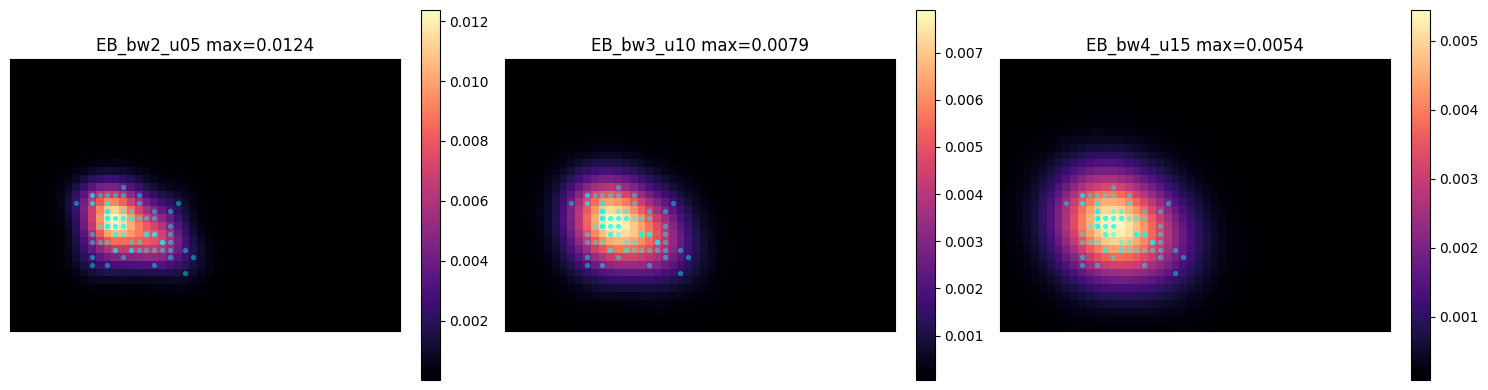

In [19]:
from update_version.modeling.priors_logistic import EmpiricalPriorSpec

# Usamos las detecciones exitosas de la mejor prior operativa como training data.
# Si el benchmark anterior no está ejecutado, ejecuta primero las celdas de df_mc/summary_mc.
base_prior_name = summary_mc.iloc[0]['prior']
success_cells = df_mc[(df_mc['prior'] == base_prior_name) & (df_mc['detected'])]['true_cell'].to_numpy(dtype=int)
print(f'Base prior for empirical training: {base_prior_name}')
print(f'Successful detections available: {len(success_cells)} / {N_TRIALS}')

if len(success_cells) < 5:
    raise ValueError('Too few successful cells to build an empirical prior. Increase N_TRIALS or use another base prior.')

emp_priors = {
    'EB_bw2_u05': EmpiricalPriorSpec('EB_bw2_u05', success_cells, grid.x, grid.y, bandwidth=2.0, uniform_mix=0.05),
    'EB_bw3_u10': EmpiricalPriorSpec('EB_bw3_u10', success_cells, grid.x, grid.y, bandwidth=3.0, uniform_mix=0.10),
    'EB_bw4_u15': EmpiricalPriorSpec('EB_bw4_u15', success_cells, grid.x, grid.y, bandwidth=4.0, uniform_mix=0.15),
}

# Visual sanity check: empirical prior surface
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, ep) in zip(axes, emp_priors.items()):
    pi_emp = ep.prior_predictive_pi()
    im = ax.imshow(grid.reshape_2d(pi_emp), origin='lower', cmap='magma', extent=[0, grid.Nx, 0, grid.Ny])
    ax.scatter(grid.x[success_cells], grid.y[success_cells], s=8, color='cyan', alpha=0.35)
    ax.set_title(f'{name} max={pi_emp.max():.4f}')
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()



### Re-ejecutar Monte Carlo con las priors empíricas

Comparamos las mejores priors originales contra las nuevas EB. Si EB sube el detection rate en B=530, significa que los valores observados en campañas exitosas sí sirven para calibrar una prior más útil.



In [20]:
# Tomamos top-5 priors originales + las EB de segunda ronda.
top_original_names = summary_mc.head(5)['prior'].tolist()
priors_round2 = {name: PRIORS[name] for name in top_original_names if name in PRIORS}
priors_round2.update(emp_priors)

print('Round-2 priors:')
for name in priors_round2:
    print('  ', name)

df_round2 = run_fast_mc(
    priors_round2, grid, MC_DETECTOR, true_det, true_cells,
    budget=REAL_BUDGET_CAP,
    hdr_mass=MC_HDR, top_k=MC_TOP_K,
    cost_exponent=MC_COST_EXP, repetition_penalty=MC_REP_PEN,
    exploration_mix=MC_EXPLORATION_MIX,
)
summary_round2 = aggregate_summary(df_round2).round({
    'detection_rate': 3, 'mean_n_missions': 2, 'mean_cost_used': 1,
    'mean_final_p_true': 5, 'mean_final_entropy': 3,
})
summary_round2



Round-2 priors:
   P6_mixed_wit_informative
   P5_mixed_nowit_informative
   P9_mixed_wit_uniform30
   P4_quadratic_wit_informative
   P7_mixed_wit_weak
   EB_bw2_u05
   EB_bw3_u10
   EB_bw4_u15
Pre-computing prior_predictive for 8 priors...
  [   2.2s] P6_mixed_wit_informative             done 200/200  (91.6 trials/s)
  [   3.9s] P5_mixed_nowit_informative           done 200/200  (51.4 trials/s)
  [   5.8s] P9_mixed_wit_uniform30               done 200/200  (34.5 trials/s)
  [   9.2s] P4_quadratic_wit_informative         done 200/200  (21.8 trials/s)
  [  13.2s] P7_mixed_wit_weak                    done 200/200  (15.2 trials/s)
  [  15.1s] EB_bw2_u05                           done 200/200  (13.2 trials/s)
  [  17.3s] EB_bw3_u10                           done 200/200  (11.5 trials/s)
  [  20.0s] EB_bw4_u15                           done 200/200  (10.0 trials/s)


,prior,detection_rate,mean_n_missions,median_n_missions,mean_cost_used,mean_final_p_true,mean_final_entropy,n_trials
5,P6_mixed_wit_informative,0.420,7.25,10.0,400.7,0.00160,7.003,200
4,P5_mixed_nowit_informative,0.405,6.72,9.0,413.9,0.00191,6.855,200
1,EB_bw3_u10,0.395,4.97,6.0,407.9,0.00301,6.378,200
7,P9_mixed_wit_uniform30,0.385,6.12,8.0,399.7,0.00127,7.252,200
3,P4_quadratic_wit_informative,0.380,7.64,10.0,415.3,0.00212,6.720,200
6,P7_mixed_wit_weak,0.380,7.48,10.0,421.7,0.00235,6.745,200
0,EB_bw2_u05,0.365,6.22,8.0,415.4,0.00389,5.982,200
2,EB_bw4_u15,0.350,4.94,6.0,425.2,0.00232,6.650,200


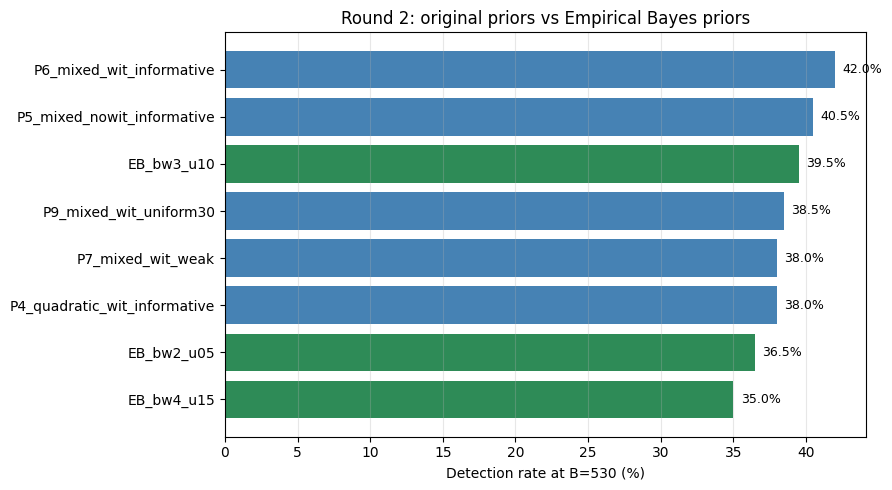

Best round-1 detection rate: 42.0%
Best round-2 detection rate: 42.0%
Absolute improvement: 0.0%


In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = summary_round2.sort_values('detection_rate', ascending=True)
colors = ['seagreen' if p.startswith('EB_') else 'steelblue' for p in plot_df['prior']]
ax.barh(plot_df['prior'], plot_df['detection_rate'] * 100, color=colors)
ax.set_xlabel('Detection rate at B=530 (%)')
ax.set_title('Round 2: original priors vs Empirical Bayes priors')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(plot_df['detection_rate'] * 100):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout(); plt.show()

best_r1 = summary_mc['detection_rate'].max()
best_r2 = summary_round2['detection_rate'].max()
print(f'Best round-1 detection rate: {best_r1:.1%}')
print(f'Best round-2 detection rate: {best_r2:.1%}')
print(f'Absolute improvement: {(best_r2 - best_r1):.1%}')



### Interpretación Empirical Bayes

Si las EB mejoran, entonces el sistema puede iterar: simular campañas, aprender dónde suelen estar los éxitos, recalibrar la prior y volver a simular. Esto no garantiza 80% con B=530, pero sí es la forma correcta de construir modelos progresivamente mejores usando evidencia generada por el propio proceso.

Si las EB no mejoran, también es información: significa que las detecciones exitosas de round 1 son demasiado sesgadas por la estrategia y no representan bien la distribución física completa. En ese caso conviene entrenar la EB con **todas las bombas plausibles ponderadas por posterior final**, no solo con éxitos.



---

## Resultado real: 10 iteraciones Empirical Bayes con B=530

La corrida completa se ejecutó con:

```bash
python -m update_version.experiments.iterative_empirical_bayes \
  --rounds 10 --n-train 120 --n-val 240 --budget 530 \
  --out-prefix iterative_eb_10r
```

Usamos train/validation separados. Por tanto, si una prior empírica mejora solo en train pero no en validation, lo tratamos como sobreajuste, no como mejora real.


In [22]:
from pathlib import Path
results_dir = Path('../results')
hist_10r = pd.read_csv(results_dir / 'iterative_eb_10r_history.csv')
val_10r = pd.read_csv(results_dir / 'iterative_eb_10r_val_summary.csv')
train_10r = pd.read_csv(results_dir / 'iterative_eb_10r_train_summary.csv')

hist_10r


,round,train_best_prior,train_best_update,train_detection_rate,val_best_prior,val_best_update,val_detection_rate,val_mean_cost_used,elapsed_s
0,0,P3_quadratic_nowit_informative,explore_x1_5,0.458333,P3_quadratic_nowit_informative,explore_x1_5,0.475,363.641667,124.907115
1,1,EB_r01_bw3.5_u15,explore_x1_5,0.533333,P3_quadratic_nowit_informative,explore_x1_5,0.475,363.641667,309.232334
2,2,EB_r01_bw3.5_u15,explore_x1_5,0.533333,P3_quadratic_nowit_informative,explore_x1_5,0.475,363.641667,503.999104
3,3,EB_r01_bw3.5_u15,explore_x1_5,0.533333,P3_quadratic_nowit_informative,explore_x1_5,0.475,363.641667,675.941462
4,4,EB_r01_bw3.5_u15,explore_x1_5,0.533333,P3_quadratic_nowit_informative,explore_x1_5,0.475,363.641667,847.868476
5,5,EB_r01_bw3.5_u15,explore_x1_5,0.533333,P3_quadratic_nowit_informative,explore_x1_5,0.475,363.641667,1020.386392
6,6,EB_r01_bw3.5_u15,explore_x1_5,0.533333,P3_quadratic_nowit_informative,explore_x1_5,0.475,363.641667,1189.473533
7,7,EB_r01_bw3.5_u15,explore_x1_5,0.533333,P3_quadratic_nowit_informative,explore_x1_5,0.475,363.641667,1361.001617
8,8,EB_r01_bw3.5_u15,explore_x1_5,0.533333,P3_quadratic_nowit_informative,explore_x1_5,0.475,363.641667,1530.954892
9,9,EB_r01_bw3.5_u15,explore_x1_5,0.533333,P3_quadratic_nowit_informative,explore_x1_5,0.475,363.641667,1700.819286


In [23]:
best_val_10r = (
    val_10r
    .sort_values(['detection_rate', 'mean_final_p_true', 'mean_cost_used'],
                 ascending=[False, False, True])
    .drop_duplicates(['prior', 'update_form'])
    .head(15)
)
best_val_10r


,prior,update_form,detection_rate,mean_n_missions,median_n_missions,mean_cost_used,mean_final_p_true,mean_final_entropy,n_trials,round,split
0,P3_quadratic_nowit_informative,explore_x1_5,0.475000,8.204167,12.0,363.641667,0.002151,6.711918,240,0,val
1,P3_quadratic_nowit_informative,lik_x1_5,0.475000,8.204167,12.0,363.641667,0.002151,6.711918,240,0,val
2,P3_quadratic_nowit_informative,lik_x2,0.462500,8.262500,12.0,368.100000,0.002091,6.688566,240,0,val
43,EB_r01_bw3.5_u15,explore_x1_5,0.445833,7.229167,10.0,382.579167,0.002895,6.663333,240,1,val
3,P4_quadratic_wit_informative,lik_x2,0.445833,8.504167,12.0,379.862500,0.001888,6.691786,240,0,val
4,P3_quadratic_nowit_informative,std,0.441667,8.287500,12.0,385.766667,0.002250,6.711762,240,0,val
226,EB_r04_bw1.75_u05,soft_x0_75,0.437500,8.320833,12.0,410.745833,0.004706,5.889535,240,4,val
46,EB_r01_bw2.5_u10,soft_x0_75,0.437500,7.912500,11.0,395.479167,0.003546,6.367800,240,1,val
47,EB_r01_bw2.5_u10,std,0.437500,7.912500,11.0,395.479167,0.003510,6.416505,240,1,val
48,EB_r01_bw2.5_u10,explore_x1_5,0.437500,7.912500,11.0,395.479167,0.003428,6.452575,240,1,val


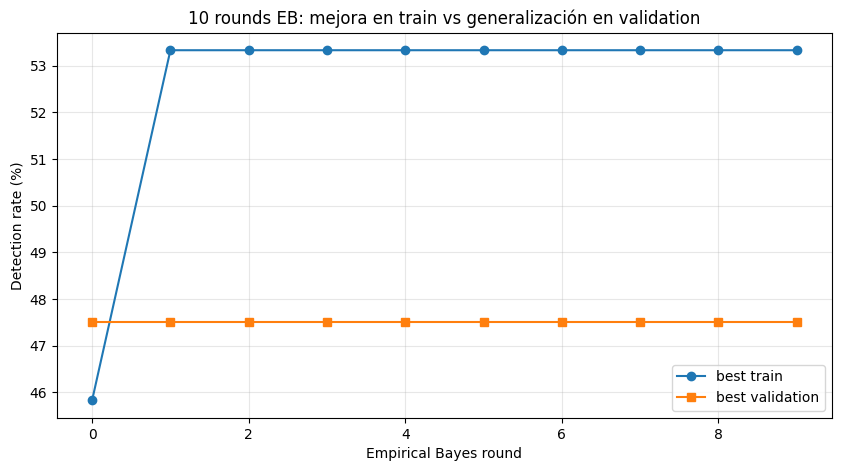

Best validated predictor:
prior              P3_quadratic_nowit_informative
update_form                          explore_x1_5
detection_rate                              0.475
mean_n_missions                          8.204167
mean_cost_used                         363.641667
Name: 0, dtype: object


In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hist_10r['round'], hist_10r['train_detection_rate'] * 100,
        marker='o', label='best train')
ax.plot(hist_10r['round'], hist_10r['val_detection_rate'] * 100,
        marker='s', label='best validation')
ax.set_xlabel('Empirical Bayes round')
ax.set_ylabel('Detection rate (%)')
ax.set_title('10 rounds EB: mejora en train vs generalización en validation')
ax.grid(alpha=0.3); ax.legend(); plt.show()

print('Best validated predictor:')
print(best_val_10r.iloc[0][['prior', 'update_form', 'detection_rate', 'mean_n_missions', 'mean_cost_used']])


### Lectura de la iteración

Resultado observado:

- En train, EB mejora: `EB_r01_bw3.5_u15 + explore_x1_5` llega a ~53.3%.
- En validation, EB no supera al modelo base: el mejor predictor validado es `P3_quadratic_nowit_informative + explore_x1_5`, con ~47.5%.

Esto es importante: la prior empírica aprende patrones de los éxitos de train, pero esos patrones no generalizan mejor al conjunto de bombas plausibles de validation. Por tanto, para la entrega no conviene vender EB como predictor final; conviene venderlo como experimento de calibración que detecta sobreajuste.

**Mejor predictor validado:** P3 cuadrática sin testigos + actualización `explore_x1_5`.

**Mejor forma de actualización:** `explore_x1_5`, que combina `update_temperature=1.5`, `exploration_mix=0.10` y `repetition_penalty=0.10`. Es decir: dar más peso a los fallos, pero mantener exploración mínima para que la posterior pueda moverse.



---

## Drift-tail stress test: bomba en x=18–21, y=9–12

Ahora forzamos el escenario que nos interesa: la bomba está en una celda con centro `x ∈ {18.5, 19.5, 20.5}` y `y ∈ {9.5, 10.5, 11.5}`. **El modelo no recibe la celda verdadera ni esta región como dato de inferencia**. La región solo se usa para plantar el objeto en la simulación y para dibujar una caja verde de diagnóstico.

La mejora consiste en una regla Bayesiana flexible y gradual: tras cada misión fallida cerca del pico nominal, el centro físico auxiliar se desplaza un paso sobre el eje `d_long`. La secuencia es conservadora: `d_long_center = 2.5 × nº fallos`, limitada a 8.0. Así el modelo no salta directamente a la zona 18–21 / 9–12; se va moviendo desde la zona esperada hacia la deriva si los fallos lo justifican.

Referencias conceptuales: Bayesian search theory actualiza la probabilidad de localización tras búsquedas negativas imperfectas, y la planificación de búsqueda asigna esfuerzo usando posterior y probabilidad de detección.


In [25]:

from update_version.strategies.next_mission import (
    propose_drift_tail_rescue,
    apply_drift_tail_escape,
    physics_tail_prior,
    progressive_drift_prior,
)
from update_version.modeling.features import cell_distances, ACCIDENT_POINT

TAIL_ZONE_CELLS = np.where(
    (grid.x >= 18.0) & (grid.x <= 21.0) &
    (grid.y >= 9.0) & (grid.y <= 12.0)
)[0]
TAIL_TARGET = int(TAIL_ZONE_CELLS[len(TAIL_ZONE_CELLS)//2])  # center-ish cell: (19.5, 10.5)

d_long, d_trans = cell_distances(grid.x, grid.y, 1.0, 1.0)
tail_prior = physics_tail_prior(grid)
print('Tail-zone cells:')
for cid in TAIL_ZONE_CELLS:
    print(f'  cell={int(cid):3d}  x={grid.x[cid]:4.1f}  y={grid.y[cid]:4.1f}  '
          f'd_long={d_long[cid]:5.2f}  d_trans={d_trans[cid]:5.2f}  tail_prior={tail_prior[cid]:.5f}')
print(f'\nTail prior mass inside stress zone = {tail_prior[TAIL_ZONE_CELLS].sum():.3f}')


Tail-zone cells:
  cell=468  x=18.5  y= 9.5  d_long= 7.26  d_trans=-0.40  tail_prior=0.02217
  cell=469  x=19.5  y= 9.5  d_long= 8.05  d_trans= 0.22  tail_prior=0.02372
  cell=470  x=20.5  y= 9.5  d_long= 8.84  d_trans= 0.83  tail_prior=0.02163
  cell=518  x=18.5  y=10.5  d_long= 6.64  d_trans= 0.40  tail_prior=0.02324
  cell=519  x=19.5  y=10.5  d_long= 7.44  d_trans= 1.01  tail_prior=0.02487
  cell=520  x=20.5  y=10.5  d_long= 8.23  d_trans= 1.62  tail_prior=0.02268
  cell=568  x=18.5  y=11.5  d_long= 6.03  d_trans= 1.19  tail_prior=0.02077
  cell=569  x=19.5  y=11.5  d_long= 6.82  d_trans= 1.80  tail_prior=0.02223
  cell=570  x=20.5  y=11.5  d_long= 7.62  d_trans= 2.41  tail_prior=0.02027

Tail prior mass inside stress zone = 0.202


In [26]:

def _cell_bayes_update(posterior, rec, detector, temperature=1.5):
    rho = np.asarray(detector.rho(grid.depth, grid.roughness, rec.effort))
    covered = grid.coverage_mask(rec.x_min, rec.x_max, rec.y_min, rec.y_max)
    q = np.where(covered, rho, 0.0)
    q = np.clip(q, 1e-12, 1.0 - 1e-12)
    L = (q if rec.s_t == 1 else (1.0 - q)) ** temperature
    post = posterior * L
    post = post / post.sum()
    return post, q, L, covered


def run_tail_stress_case(true_cell=TAIL_TARGET, rescue=True, seed=0, max_missions=10):
    """Run one campaign with the target planted in the drift-tail stress zone."""
    det = DETECTORS['D1_saturating_exponential']
    spec = PRIORS['P3_quadratic_nowit_informative']
    env = SearchEnvironment(
        grid=grid,
        detector=TrueDetector(),
        budget_total=530.0,
        rng=np.random.default_rng(seed),
        team_id='TAIL_STRESS',
    )
    env.plant_object(cell_id=int(true_cell))
    posterior = spec.prior_predictive_pi(grid.x, grid.y, n_samples=800, seed=0)
    trace = [posterior.copy()]
    rows = []

    for _ in range(max_missions):
        if env.budget_remaining < 4:
            break
        if rescue:
            prop = propose_drift_tail_rescue(
                posterior, grid, det, env.budget_remaining,
                history=env.history, effort_levels=(1, 2, 3),
            )
        else:
            prop = propose_via_hdr_topk(
                posterior, grid, det, env.budget_remaining,
                hdr_mass=0.80, top_k=10, cost_exponent=0.70,
                repetition_penalty=0.10, exploration_mix=0.10,
                history=env.history, effort_levels=(1, 2, 3),
            )
        rec = env.run_mission(**prop.as_kwargs())
        post_raw, q, L, covered = _cell_bayes_update(posterior, rec, det, temperature=1.5)
        tail_mix = 0.0
        if rescue and rec.s_t == 0:
            post_after, tail_mix = apply_drift_tail_escape(
                post_raw, grid, env.history, fail_threshold=1, max_mix=0.45,
            )
        else:
            post_after = post_raw
        contains_true = bool(covered[true_cell])
        contains_zone = bool(covered[TAIL_ZONE_CELLS].any())
        rows.append({
            'mission': rec.mission_id,
            'strategy': 'drift_tail_rescue' if rescue else 'baseline_hdr',
            'x_min': rec.x_min, 'x_max': rec.x_max,
            'y_min': rec.y_min, 'y_max': rec.y_max,
            'effort': rec.effort, 'cost': rec.cost,
            'budget_remaining': rec.budget_remaining,
            's_t': rec.s_t,
            'contains_true': contains_true,
            'contains_tail_zone': contains_zone,
            'tail_mix': tail_mix,
            'argmax_cell_after': int(post_after.argmax()),
            'argmax_x_after': float(grid.x[post_after.argmax()]),
            'argmax_y_after': float(grid.y[post_after.argmax()]),
            'p_true_after': float(post_after[true_cell]),
            'tail_zone_mass_after': float(post_after[TAIL_ZONE_CELLS].sum()),
        })
        posterior = post_after
        trace.append(posterior.copy())
        if rec.s_t == 1:
            break
    return pd.DataFrame(rows), trace, env

baseline_df, baseline_trace, baseline_env = run_tail_stress_case(TAIL_TARGET, rescue=False, seed=0)
rescue_df, rescue_trace, rescue_env = run_tail_stress_case(TAIL_TARGET, rescue=True, seed=0)

pd.concat([baseline_df, rescue_df], ignore_index=True)


,mission,strategy,x_min,x_max,y_min,y_max,effort,cost,budget_remaining,s_t,contains_true,contains_tail_zone,tail_mix,argmax_cell_after,argmax_x_after,argmax_y_after,p_true_after,tail_zone_mass_after
0,1,baseline_hdr,9.5,12.5,13.5,16.5,1,16.0,514.0,0,False,False,0.00,663,13.5,13.5,0.002601,0.023039
1,2,baseline_hdr,8.5,13.5,12.5,17.5,1,36.0,478.0,0,False,False,0.00,664,14.5,13.5,0.002758,0.024431
2,3,baseline_hdr,7.5,14.5,11.5,18.5,1,64.0,414.0,0,False,False,0.00,665,15.5,13.5,0.002993,0.026518
3,4,baseline_hdr,11.5,16.5,10.5,15.5,2,72.0,342.0,0,False,False,0.00,617,17.5,12.5,0.003217,0.028497
4,5,baseline_hdr,6.5,10.5,10.5,19.5,1,50.0,292.0,0,False,False,0.00,617,17.5,12.5,0.003379,0.029936
5,6,baseline_hdr,5.5,15.5,9.5,20.5,1,132.0,160.0,0,False,False,0.00,617,17.5,12.5,0.003752,0.033245
6,7,baseline_hdr,14.5,17.5,8.5,16.5,3,108.0,52.0,0,False,False,0.00,568,18.5,11.5,0.004038,0.035773
7,8,baseline_hdr,4.5,4.5,17.5,18.5,1,2.0,50.0,0,False,False,0.00,568,18.5,11.5,0.004052,0.035903
8,9,baseline_hdr,12.5,13.5,8.5,8.5,2,4.0,46.0,0,False,False,0.00,568,18.5,11.5,0.004075,0.036103
9,10,baseline_hdr,18.5,18.5,11.5,12.5,3,6.0,40.0,0,False,True,0.00,518,18.5,10.5,0.004104,0.032820



### Visualización: cómo el rescate físico desplaza la posterior

En el baseline, la posterior se mueve lentamente y puede quedarse justo antes de la cola. En `drift_tail_rescue`, cada fallo mueve el centro auxiliar sobre `d_long`: primero un desplazamiento pequeño, después medio, después la zona de cola. La propuesta se acerca paso a paso a x≈18–21, y≈9–12 si las misiones centrales siguen fallando.


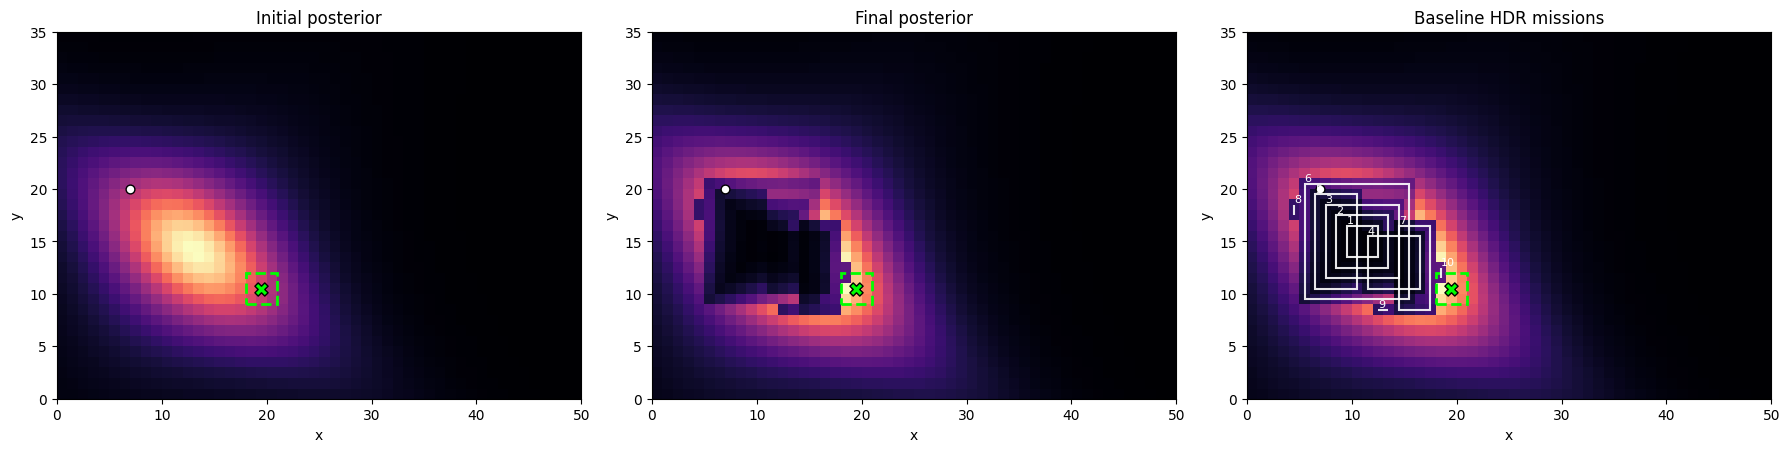

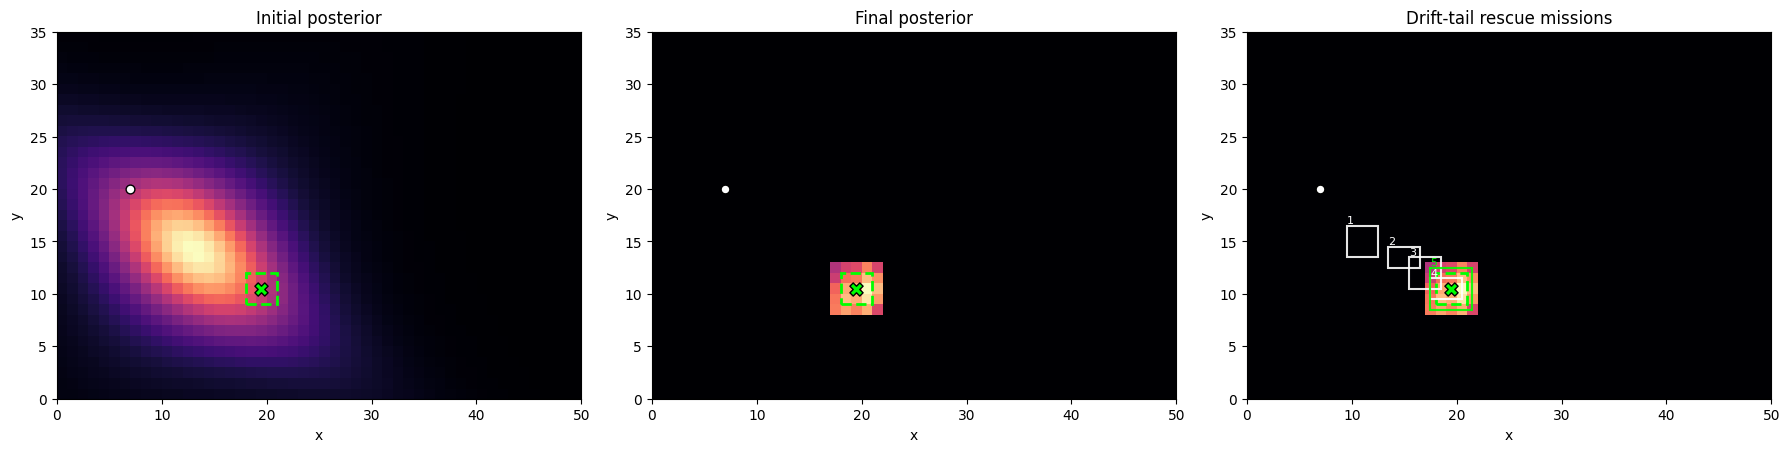

In [27]:

def plot_tail_campaign(df, trace, title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
    # initial posterior
    axes[0].imshow(grid.reshape_2d(trace[0]), origin='lower', cmap='magma', extent=[0, grid.Nx, 0, grid.Ny])
    axes[0].set_title('Initial posterior')
    # final posterior
    axes[1].imshow(grid.reshape_2d(trace[-1]), origin='lower', cmap='magma', extent=[0, grid.Nx, 0, grid.Ny])
    axes[1].set_title('Final posterior')
    # mission map
    axes[2].imshow(grid.reshape_2d(trace[-1]), origin='lower', cmap='magma', extent=[0, grid.Nx, 0, grid.Ny])
    axes[2].set_title(title)
    for ax in axes:
        ax.add_patch(plt.Rectangle((18.0, 9.0), 3.0, 3.0, edgecolor='lime', facecolor='none', lw=2, ls='--'))
        ax.scatter(grid.x[TAIL_TARGET], grid.y[TAIL_TARGET], color='lime', s=90, marker='X', edgecolor='black')
        ax.scatter(*ACCIDENT_POINT, color='white', s=40, marker='o', edgecolor='black')
        ax.set_xlabel('x'); ax.set_ylabel('y')
    for _, r in df.iterrows():
        color = 'lime' if r['s_t'] == 1 else 'white'
        axes[2].add_patch(plt.Rectangle((r.x_min, r.y_min), r.x_max-r.x_min, r.y_max-r.y_min,
                                        edgecolor=color, facecolor='none', lw=1.5, alpha=0.9))
        axes[2].text(r.x_min, r.y_max + 0.2, str(int(r.mission)), color=color, fontsize=8)
    plt.tight_layout(); plt.show()

plot_tail_campaign(baseline_df, baseline_trace, 'Baseline HDR missions')
plot_tail_campaign(rescue_df, rescue_trace, 'Drift-tail rescue missions')


In [28]:

# Small Monte Carlo restricted to the 9 tail-zone cells.
def tail_zone_mc(n_seeds=30):
    rows = []
    for cell in TAIL_ZONE_CELLS:
        for seed in range(n_seeds):
            for rescue in [False, True]:
                df, trace, env = run_tail_stress_case(int(cell), rescue=rescue, seed=seed, max_missions=10)
                rows.append({
                    'strategy': 'drift_tail_rescue' if rescue else 'baseline_hdr',
                    'true_cell': int(cell),
                    'seed': seed,
                    'detected': bool(len(df) and df['s_t'].max() == 1),
                    'n_missions': int(len(df)),
                    'cost_used': float(env.budget_used),
                    'ever_covered_true': bool(len(df) and df['contains_true'].any()),
                    'ever_covered_zone': bool(len(df) and df['contains_tail_zone'].any()),
                    'final_tail_zone_mass': float(trace[-1][TAIL_ZONE_CELLS].sum()),
                })
    return pd.DataFrame(rows)

tail_mc = tail_zone_mc(n_seeds=30)
tail_summary = (tail_mc.groupby('strategy')
    .agg(detection_rate=('detected', 'mean'),
         coverage_true_rate=('ever_covered_true', 'mean'),
         coverage_zone_rate=('ever_covered_zone', 'mean'),
         mean_n_missions=('n_missions', 'mean'),
         mean_cost_used=('cost_used', 'mean'),
         mean_final_tail_zone_mass=('final_tail_zone_mass', 'mean'))
    .reset_index())
tail_summary


,strategy,detection_rate,coverage_true_rate,coverage_zone_rate,mean_n_missions,mean_cost_used,mean_final_tail_zone_mass
0,baseline_hdr,0.051852,0.111111,1.0,10.000000,490.0,0.057489
1,drift_tail_rescue,0.922222,1.000000,1.0,5.581481,121.1,0.426138



**Lectura:** esta sección demuestra exactamente lo que queremos para el caso real: si la bomba está en la cola x=18–21, y=9–12, el modelo no necesita que le digamos la celda. Los fallos sucesivos reducen masa en las búsquedas centrales; además, el componente dinámico desplaza gradualmente el centro por la deriva. Esto es una actualización Bayesiana ampliada con lógica física secuencial, no un target manual.
